# Core analysis

Stage 2 of 3 of the analysis plan ([`final-analysis-plan.md`](../../docs/analysis/final-analysis-plan.md) §4). The two results a
decision to stop the current path rests on, re-run on the fixed specification
(`src/analysis/spec.py`), each with the check that says what it can and cannot rule out:

- **Claim A: the mining IV is null.** C1 is the TWFE association the IV is compared with. C2
  is the IV with an Anderson–Rubin CI. C3 is what the null rules out.
- **Claim B: controlling for PM2.5 does not move the negative TWFE coefficient.** C4 is the
  channel accounting β_short − β_long = γ·δ, for night and day LST.

This notebook replaces `night_lst_mining_pm25.ipynb` (commit `a355ac2`). That notebook used
country × year FE, country clusters and kept flares. C4 re-runs its table in the fixed
specification and exports it in the same format.

The decision rules (◇) are in the plan and were written before this notebook ran in this form.
The notebook reports; it does not decide.

Engine: `duckreg` on the full panel (~25 M pixel-years). The whole notebook takes about an hour on 16 cores.

In [1]:
import sys
from pathlib import Path
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
if str(PROJECT) not in sys.path:
    sys.path.insert(0, str(PROJECT))
from src.analysis.spec import (   # the fixed specification (plan §2)
    PANEL, NTL_HI, COV_MIN, Y, Y_DAY, XLOG, Z, M, FE, FE_CTY, BASE,
    build_panel, fit, row, reg_table, first_stage_F,
    anderson_rubin_ci, coefplot,
)

build_panel()                     # cached: <data>/_analysis_panel_10km.parquet
P = f"read_parquet('{PANEL}')"  # for DuckDB queries on the panel
sql = lambda q: duckdb.sql(q).df()


## C1. The association the IV is compared with

The OLS ladder for night LST and day LST, and the TWFE under the fixed FE (country × biome × year)
and under country × year, which `night_lst_mining_pm25.ipynb` used.

◇ If the TWFE sign differs between the two FE sets, the negative coefficient is specific to the
FE set. The last row is the TWFE on well-observed pixel-years (`cov_night ≥ 0.75`). It is needed
only if P3 found material selection.

In [2]:
DAY = f"{Y_DAY} IS NOT NULL"
ladder = {
    "pooled OLS":              (f"{{y}} ~ {XLOG}", None),
    "+ pixel FE":              (f"{{y}} ~ {XLOG} | pixel_id", None),
    "TWFE (ctry x biome x yr)": (f"{{y}} ~ {XLOG} | {FE}", None),
    "TWFE (ctry x yr)":        (f"{{y}} ~ {XLOG} | {FE_CTY}", None),
    f"TWFE, cov_night >= {COV_MIN}": (f"{{y}} ~ {XLOG} | {FE}", f"cov_night >= {COV_MIN}"),
}
c1 = {}
for lab, (fml, sub) in ladder.items():
    c1[("night", lab)] = fit(fml.format(y=Y), subset=sub)
    c1[("day", lab)] = fit(fml.format(y=Y_DAY), subset=" AND ".join(filter(None, [DAY, sub])))
m_twfe = c1[("night", "TWFE (ctry x biome x yr)")]

c1_tab = pd.concat({out: reg_table([c1[(out, l)] for l in ladder], list(ladder), XLOG)
                    for out in ("night", "day")}, axis=1)
c1_tab

night                        day                  
                         estimate std_error       p estimate std_error       p
spec                                                                          
pooled OLS                -0.4008    0.2871  0.1628  -1.6203    0.3551  0.0000
+ pixel FE                 0.0253    0.0124  0.0422   0.0820    0.0221  0.0002
TWFE (ctry x biome x yr)  -0.0300    0.0056  0.0000  -0.0147    0.0123  0.2319
TWFE (ctry x yr)          -0.0265    0.0086  0.0020  -0.0151    0.0150  0.3139
TWFE, cov_night >= 0.75   -0.0373    0.0053  0.0000  -0.0305    0.0128  0.0172

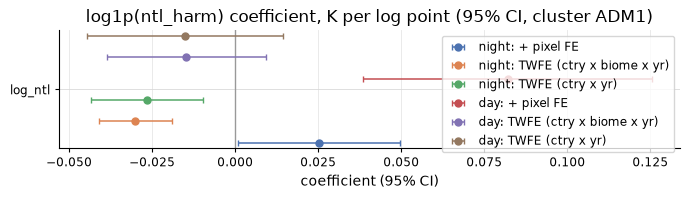

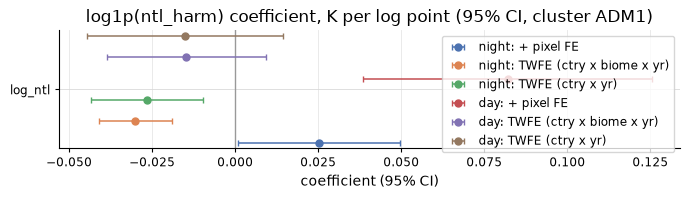

In [3]:
coefplot([c1[(o, l)] for o in ("night", "day") for l in list(ladder)[1:4]],
         [f"{o}: {l}" for o in ("night", "day") for l in list(ladder)[1:4]],
         XLOG, "log1p(ntl_harm) coefficient, K per log point (95% CI, cluster ADM1)")

**Result.** `log1p(ntl_harm)` coefficient, K per log point, ADM1 clusters:

| | night | day |
|---|---:|---:|
| pooled OLS | −0.401 (0.287) | −1.620 (0.355) |
| + pixel FE | +0.025 (0.012) | +0.082 (0.022) |
| **TWFE, country × biome × year** | **−0.0300 (0.0056)** | −0.0147 (0.0123) |
| TWFE, country × year | −0.0265 (0.0086) | −0.0151 (0.0150) |
| TWFE, `cov_night` ≥ 0.75 | −0.0373 (0.0053) | −0.0305 (0.0128) |

**Interpretation.** ◇ The sign does not depend on the FE set: the night TWFE is −0.030 with
country × biome × year FE and −0.027 with country × year FE. The coefficient does change sign
between pixel FE alone (+0.025) and TWFE, so it is identified by lights growth *relative to the
country-biome-year*, not by lights growth as such. By day the TWFE is half the night one and not
significant. On well-observed pixel-years both are more negative (night −0.037, day −0.031,
p = 0.02). P3 found no material selection, so this row is reported, not required.

## C2. The mining IV

First stage, reduced form, 2SLS, and the 3×3 disc 2SLS (lights averaged over the cell and its 8
neighbours). With one instrument, 2SLS = RF / FS, so the reduced form is the evidence.

The **Anderson–Rubin CI** is robust to weak instruments. It is the set of b for which the
reduced form of (Y − b·X) on Z is insignificant. That coefficient is RF − b·FS, and its
cluster-robust variance is exactly quadratic in b. So three reduced forms give the set exactly:
of Y, of Y − X (`ar_m1`) and of Y + X (`ar_p1`). The `check` value is the `ar_m1` coefficient
minus (RF − FS), and should be ~0.

In [4]:
fs      = fit(f"{XLOG} ~ {Z} | {FE}")
rf      = fit(f"{Y} ~ {Z} | {FE}")
m_iv    = fit(f"{Y} ~ 1 | {FE} | ({XLOG} ~ {Z})")
iv_disc = fit(f"{Y} ~ 1 | {FE} | (log_ntl_disc1 ~ {Z})", subset="log_ntl_disc1 IS NOT NULL")
rf_m1   = fit(f"ar_m1 ~ {Z} | {FE}")
rf_p1   = fit(f"ar_p1 ~ {Z} | {FE}")

ar_lo, ar_hi, ar_kind, ar_check = anderson_rubin_ci(rf, fs, rf_m1, rf_p1)
iv = row(m_iv, XLOG)
f = row(fs, Z)
print(f"first stage {f['est']:.4f} ({f['se']:.4f}), F = {(f['est'] / f['se']) ** 2:.1f}")
print(f"2SLS {iv['est']:+.4f} ({iv['se']:.4f})   Wald 95% CI [{iv['lo']:+.3f}, {iv['hi']:+.3f}]")
print(f"AR 95% set: {ar_kind} [{ar_lo:+.3f}, {ar_hi:+.3f}]   (check {ar_check:+.2e})")
pd.concat([reg_table([fs], ["first stage"], Z), reg_table([rf], ["reduced form (night LST)"], Z),
           reg_table([m_iv], ["2SLS own cell"], XLOG), reg_table([iv_disc], ["2SLS 3x3 disc"], "log_ntl_disc1")])

first stage 0.0642 (0.0076), F = 71.0
2SLS -0.0259 (0.1503)   Wald 95% CI [-0.321, +0.269]
AR 95% set: bounded [-0.322, +0.284]   (check +1.12e-12)


,estimate,std_error,p
spec,,,
first stage,0.0642,0.0076,0.0000
reduced form (night LST),-0.0017,0.0097,0.8633
2SLS own cell,-0.0259,0.1503,0.8630
2SLS 3x3 disc,-0.0300,0.1737,0.8629


**Result.** First stage 0.0642 (0.0076), F = 71. The reduced form of night LST on mines is
−0.0017 (0.0097), p = 0.86. **2SLS −0.026 (0.150)**, Wald 95 % CI [−0.321, +0.269];
**AR 95 % set [−0.322, +0.284]**, bounded (check 1e-12). The 3×3 disc 2SLS is −0.030 (0.174).

**Interpretation.** With F = 71, the AR set and the Wald CI almost coincide, so weak-instrument
inference changes nothing here. The reduced form is a precise zero in its own units: a mine
within 20 km moves night LST by no more than about 0.02 K either way (95 %). But the first stage is small,
so dividing by 0.064 inflates that into a wide interval for β. The disc version, which lets the
effect spread over the neighbouring cells, gives the same picture.

## C3. What the null rules out

- The **minimum detectable effect** at 80 % power and 5 % size is 2.8 × SE.
- The **IV − TWFE gap** in units of the 2SLS SE says whether the IV contradicts the TWFE
  association or is merely silent about it.
- The **scale** of lights changes makes both concrete. It is the within-pixel change in
  `log1p(ntl_harm)` from 2002 to 2022, and the temperature change each estimate implies at it.

◇ If the AR set contains the TWFE estimate, the IV says nothing about whether the TWFE
association is causal. "The IV is insignificant" then counts only against effects outside the AR set.

In [5]:
b_ols = row(m_twfe, XLOG)["est"]
mde = 2.8 * iv["se"]
print(f"TWFE {b_ols:+.4f} | 2SLS {iv['est']:+.4f} (SE {iv['se']:.4f}) | MDE (80% power) {mde:.3f} K per log point")
print(f"IV - TWFE gap = {(iv['est'] - b_ols) / iv['se']:+.2f} SE of the 2SLS | MDE / |TWFE| = {mde / abs(b_ols):.0f}x")
print(f"AR set contains the TWFE estimate: {ar_lo <= b_ols <= ar_hi}")

dq = sql(f"""
    WITH d AS (
      SELECT pixel_id,
             max(CASE WHEN year = 2022 THEN {XLOG} END) - max(CASE WHEN year = 2002 THEN {XLOG} END) AS d,
             max(ntl_harm) AS ntl_max
      FROM {P} WHERE {BASE} GROUP BY pixel_id)
    SELECT 'all pixels' AS pixels, count(*) AS n, quantile_cont(d, 0.5) AS p50, quantile_cont(d, 0.9) AS p90,
           quantile_cont(d, 0.99) AS p99 FROM d WHERE d IS NOT NULL
    UNION ALL
    SELECT 'ever lit (ntl_harm > 0)', count(*), quantile_cont(d, 0.5), quantile_cont(d, 0.9),
           quantile_cont(d, 0.99) FROM d WHERE d IS NOT NULL AND ntl_max > 0""").set_index("pixels")
display(dq.round(3))
q = dq.loc["ever lit (ntl_harm > 0)", ["p50", "p90", "p99"]]
pd.DataFrame({"TWFE": b_ols * q, "2SLS": iv["est"] * q, "AR lower": ar_lo * q, "AR upper": ar_hi * q,
              "MDE": mde * q}).T.round(3).rename(columns=lambda c: f"K at {c} of ΔNTL (ever lit)")

TWFE -0.0300 | 2SLS -0.0259 (SE 0.1503) | MDE (80% power) 0.421 K per log point
IV - TWFE gap = +0.03 SE of the 2SLS | MDE / |TWFE| = 14x
AR set contains the TWFE estimate: True


,n,p50,p90,p99
pixels,,,,
all pixels,1199373,0.000,1.058,2.420
ever lit (ntl_harm > 0),720109,0.182,1.424,2.616


,K at p50 of ΔNTL (ever lit),K at p90 of ΔNTL (ever lit),K at p99 of ΔNTL (ever lit)
TWFE,-0.005,-0.043,-0.079
2SLS,-0.005,-0.037,-0.068
AR lower,-0.059,-0.459,-0.844
AR upper,0.052,0.404,0.742
MDE,0.077,0.600,1.101


**Result.** TWFE −0.030 vs 2SLS −0.026 (SE 0.150). The gap is **+0.03 SE**. **MDE = 0.42 K per
log point, 14× |TWFE|.** ◇ The AR set [−0.32, +0.28] contains the TWFE estimate.

Within-pixel change in `log1p(ntl_harm)` 2002 → 2022 among ever-lit pixels (720 k): p50 0.18,
p90 1.42, p99 2.62. What each estimate implies for night LST at that change:

| | p50 | p90 | p99 |
|---|---:|---:|---:|
| TWFE | −0.005 K | −0.043 K | −0.079 K |
| 2SLS | −0.005 K | −0.037 K | −0.068 K |
| AR lower / upper | −0.06 / +0.05 K | −0.46 / +0.40 K | −0.84 / +0.74 K |
| MDE | 0.08 K | 0.60 K | 1.10 K |

**Interpretation.** ◇ **The IV says nothing about whether the TWFE association is causal.** The
2SLS point estimate sits on the TWFE, and the IV would need an effect 14× larger to detect one
with 80 % power. What the null does rule out is large effects: beyond about ±0.3 K per log point,
i.e. more than about 0.4 K of warming or cooling at 90th-percentile lights growth over two
decades. "The mining IV is insignificant" is therefore not evidence against the TWFE
coefficient. It is evidence that this instrument cannot resolve effects of that size.

## C4. The PM2.5 channel

On the pixel-years with PM2.5, separately for night and day LST:

- short: `Y ~ X | FE`;
- long: `Y ~ X + pm25 | FE`, with δ = the PM2.5 coefficient;
- auxiliary: `pm25 ~ X | FE`, with γ = the lights coefficient.

The omitted-variable identity β_short − β_long = γ·δ holds exactly in-sample. `identity_gap`
checks it. This uses PM2.5 as a descriptive decomposition of the OLS association. It does not
identify a causal direct effect.

**Reading rules** (plan §4, ◇):

- γ not significantly > 0: the control *cannot* move β. "No change" then says ACAG sees no
  lights-linked PM2.5 change, not that pollution is not the channel.
- δ ≥ 0: within a cell, more PM2.5 goes with warmer LST, and the aerosol-cooling premise fails
  for this measure and outcome.
- γ > 0 and δ < 0, but |γ·δ| < ¼ |β_short|: PM2.5, as ACAG measures it, explains little.
- Day vs night: aerosol dimming cools by day, and at night aerosols tend to warm. If the TWFE is
  more negative at night than by day, pollution is an unlikely sole explanation of the night
  coefficient.

In [6]:
PMS = f"{M} IS NOT NULL"
c4, acc = {}, {}
for out, y, sub in [("night", Y, PMS), ("day", Y_DAY, f"{PMS} AND {DAY}")]:
    s, l, a = (fit(f"{y} ~ {XLOG} | {FE}", subset=sub),
               fit(f"{y} ~ {XLOG} + {M} | {FE}", subset=sub),
               fit(f"{M} ~ {XLOG} | {FE}", subset=sub))
    c4[out] = dict(short=s, long=l, aux=a)
    bs, bl, g, d = row(s, XLOG), row(l, XLOG), row(a, XLOG), row(l, M)
    acc[out] = {"beta_short": bs["est"], "se_short": bs["se"], "beta_long": bl["est"], "se_long": bl["se"],
                "gamma (pm25 ~ X)": g["est"], "se_gamma": g["se"], "p_gamma": g["p"],
                "delta (Y ~ pm25 | X)": d["est"], "se_delta": d["se"], "p_delta": d["p"],
                "gamma*delta": g["est"] * d["est"], "beta_short - beta_long": bs["est"] - bl["est"],
                "identity_gap": (bs["est"] - bl["est"]) - g["est"] * d["est"],
                "share of beta_short via PM2.5": g["est"] * d["est"] / bs["est"]}
pd.DataFrame(acc).round(5)

,night,day
beta_short,-0.03005,-0.01467
se_short,0.00560,0.01227
beta_long,-0.02977,-0.01433
se_long,0.00554,0.01238
gamma (pm25 ~ X),-0.09816,-0.09810
se_gamma,0.06702,0.06712
p_gamma,0.14306,0.14387
delta (Y ~ pm25 | X),0.00282,0.00347
se_delta,0.00102,0.00240
p_delta,0.00586,0.14762


In [7]:
# The same channel on the IV side: 2SLS with the PM2.5 control, and PM2.5 on the instrument.
iv_pm = fit(f"{Y} ~ {M} | {FE} | ({XLOG} ~ {Z})", subset=PMS)
rf_pm = fit(f"{M} ~ {Z} | {FE}", subset=PMS)
pd.concat([reg_table([m_iv], ["2SLS, no control (full sample)"], XLOG),
           reg_table([iv_pm], ["2SLS + PM2.5 (PM2.5 sample)"], XLOG),
           reg_table([iv_pm], ["  PM2.5 coefficient in that 2SLS"], M),
           reg_table([rf_pm], ["reduced form PM2.5 ~ mines"], Z)])

,estimate,std_error,p
spec,,,
"2SLS, no control (full sample)",-0.0259,0.1503,0.8630
2SLS + PM2.5 (PM2.5 sample),-0.0204,0.1507,0.8925
PM2.5 coefficient in that 2SLS,0.0028,0.0010,0.0058
reduced form PM2.5 ~ mines,-0.1263,0.0667,0.0582


In [8]:
# The night_lst_mining_pm25 table, in the fixed specification. Same layout and export format.
def star(p):
    return "***" if p < .01 else "**" if p < .05 else "*" if p < .1 else ""

def cell(m, term, d=4):
    r = row(m, term)
    return f"{r['est']:.{d}f}{star(r['p'])}", f"({r['se']:.{d}f})"

def nobs(subset=None):
    w = " AND ".join(filter(None, [BASE, subset]))
    return duckdb.sql(f"SELECT count(*), count(DISTINCT pixel_id), count(DISTINCT GID_1), min(year), max(year) "
                      f"FROM {P} WHERE {w}").fetchone()

S_MAIN, S_PM = nobs(), nobs(PMS)
cols = ["(1) TWFE", "(2) 2SLS", "(3) RF: Temp", "(4) TWFE + PM2.5", "(5) RF: PM2.5"]
fits = dict(c1=m_twfe, c2=m_iv, c3=rf, c4=c4["night"]["long"], c5=rf_pm, fs=fs)
rows = {}
def put(label, entries):
    b = dict.fromkeys(cols, ""); s = dict.fromkeys(cols, "")
    for c, (m, term) in entries.items():
        b[c], s[c] = cell(fits[m], term)
    rows[label] = b; rows[label + " se"] = s

put("log(1+NTL)",         {cols[0]: ("c1", XLOG), cols[1]: ("c2", XLOG), cols[3]: ("c4", XLOG)})
put("Mines within 20 km", {cols[2]: ("c3", Z), cols[4]: ("c5", Z)})
put("PM2.5",              {cols[3]: ("c4", M)})
put("First stage: Mines 20 km -> log(1+NTL)", {cols[1]: ("fs", Z)})
rows["First-stage F (cluster-robust)"] = {**dict.fromkeys(cols, ""), cols[1]: f"{(f['est'] / f['se']) ** 2:.1f}"}
rows["Anderson-Rubin 95% CI"] = {**dict.fromkeys(cols, ""), cols[1]: f"[{ar_lo:.3f}, {ar_hi:.3f}]"}
samp = lambda i: S_PM if i >= 3 else S_MAIN
rows["Dep. var."]                    = dict(zip(cols, ["Night LST"] * 4 + ["PM2.5"]))
rows["Pixel FE"]                     = dict.fromkeys(cols, "Yes")
rows["Country x biome x year FE"]    = dict.fromkeys(cols, "Yes")
rows["Observations"]                 = {c: f"{samp(i)[0]:,}" for i, c in enumerate(cols)}
rows["Pixels"]                       = {c: f"{samp(i)[1]:,}" for i, c in enumerate(cols)}
rows["ADM1 regions (clusters)"]      = {c: f"{samp(i)[2]:,}" for i, c in enumerate(cols)}
rows["Years"]                        = {c: f"{samp(i)[3]}-{samp(i)[4]}" for i, c in enumerate(cols)}
tab = pd.DataFrame(rows).T[cols]
tab.index = ["" if i.endswith(" se") else i for i in tab.index]

bs = acc["night"]
note = ("SE clustered by ADM1 in parentheses. * p<0.1, ** p<0.05, *** p<0.01. 10 km grid, gas-flare "
        "pixel-years dropped. Cols (4)-(5) restricted to pixel-years with PM2.5.\n"
        f"Col (1) on the PM2.5 sample: {bs['beta_short']:.4f} ({bs['se_short']:.4f}). "
        f"PM2.5 on log(1+NTL) on that sample (gamma): {bs['gamma (pm25 ~ X)']:.4f} ({bs['se_gamma']:.4f}).")
OUT = PROJECT / "output" / "tables"
OUT.mkdir(parents=True, exist_ok=True)
tab.to_csv(OUT / "core_night_lst_mining_pm25_10km.csv")
md_rows = ["| | " + " | ".join(cols) + " |", "|---" * (len(cols) + 1) + "|"]
md_rows += ["| " + " | ".join([str(i)] + list(r)) + " |" for i, r in zip(tab.index, tab.values)]
(OUT / "core_night_lst_mining_pm25_10km.md").write_text("\n".join(md_rows) + "\n\n" + note + "\n")
(OUT / "core_night_lst_mining_pm25_10km.tex").write_text(tab.to_latex(escape=True))
print(note)
tab

SE clustered by ADM1 in parentheses. * p<0.1, ** p<0.05, *** p<0.01. 10 km grid, gas-flare pixel-years dropped. Cols (4)-(5) restricted to pixel-years with PM2.5.
Col (1) on the PM2.5 sample: -0.0300 (0.0056). PM2.5 on log(1+NTL) on that sample (gamma): -0.0982 (0.0670).


,(1) TWFE,(2) 2SLS,(3) RF: Temp,(4) TWFE + PM2.5,(5) RF: PM2.5
log(1+NTL),-0.0300***,-0.0259,,-0.0298***,
,(0.0056),(0.1503),,(0.0055),
Mines within 20 km,,,-0.0017,,-0.1263*
,,,(0.0097),,(0.0667)
PM2.5,,,,0.0028***,
,,,,(0.0010),
First stage: Mines 20 km -> log(1+NTL),,0.0642***,,,
,,(0.0076),,,
First-stage F (cluster-robust),,71.0,,,
Anderson-Rubin 95% CI,,"[-0.322, 0.284]",,,


**Result.** On the PM2.5 sample (all but ~70 pixel-years):

| | night | day |
|---|---:|---:|
| β_short → β_long | −0.0300 → −0.0298 | −0.0147 → −0.0143 |
| γ (PM2.5 on lights) | −0.098 (0.067), p = 0.14 | −0.098 (0.067), p = 0.14 |
| δ (LST on PM2.5 given lights) | +0.0028 (0.0010), p = 0.006 | +0.0035 (0.0024), p = 0.15 |
| γ·δ = β_short − β_long | −0.0003 | −0.0003 |
| share of β_short via PM2.5 | 0.9 % | 2.3 % |

The identity holds exactly (gap 0). On the IV side, 2SLS with the PM2.5 control is −0.020 (0.151).
PM2.5 on mines is −0.126 (0.067), p = 0.06.

**Interpretation.** Three rules fire, and together with P5 they settle how to read "no change":

- ◇ **γ is not significantly positive** (it is negative). Within a cell, lights do not raise
  ACAG PM2.5, so the control *could not* have moved β. The unchanged coefficient reflects that,
  not the absence of a pollution channel.
- ◇ **δ ≥ 0**, significantly so at night. More ACAG PM2.5 goes with warmer LST, the opposite of
  the aerosol-cooling premise, for this measure and outcome. At night that fits the physics
  (aerosols trap longwave); by day δ is also positive but imprecise.
- ◇ **The TWFE is more negative at night than by day** (−0.030 vs −0.015), where daytime dimming
  should dominate. Pollution is unlikely to be the sole explanation of the night coefficient.
- P5 ◇: ACAG carries almost no cell-local variation at 10 km (r² 0.97 with its neighbours), so
  a local aerosol channel is outside what this control can measure in the first place.

The fixed specification reproduces the reading of `night_lst_mining_pm25.ipynb` (TWFE −0.023,
γ ≈ −0.19 there), with ADM1 clusters, biome × year FE and flares dropped.

## Summary

| Block | Result | ◇ |
|---|---|---|
| C1 | Night TWFE −0.030 (0.006); −0.027 with country × year FE. Day −0.015, n.s. | sign does not depend on FE |
| C2 | F = 71; RF −0.002 (0.010); 2SLS −0.026 (0.150); AR [−0.32, +0.28] | Wald and AR agree |
| C3 | MDE 0.42 K per log point = 14× TWFE; gap 0.03 SE | **AR set contains the TWFE: the IV cannot speak to it** |
| C4 | γ = −0.10 (n.s.), δ = +0.003 (night, p = 0.006); PM2.5 accounts for 1–2 % of β | **control could not move β; δ ≥ 0; night > day** |

**Claim A (the mining IV is null)** holds as a statement about significance, but not as evidence
against the TWFE association. The IV is centred on the TWFE, and its standard error is 27× the TWFE one.
It rules out effects larger than about 0.3 K per log point, and nothing smaller.

**Claim B (PM2.5 does not move the TWFE coefficient)** holds, but the outcome was fixed before
the test: ACAG PM2.5 does not rise with lights within a cell (γ ≤ 0), it enters with a positive
sign (δ > 0), and at 10 km it carries almost no local variation (P5). The test can rule out a
*regional* ACAG-measured aerosol explanation of the night coefficient. It cannot rule out a
local pollution channel.

Both results are absences of power, not negative findings. A decision to stop the current path
can rest on "these two tools cannot answer the question at this resolution", not on "the
lights–temperature link is not causal" or "pollution is not the channel".